In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv

load_dotenv()
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [3]:
conn = psycopg2.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    port=os.getenv('DB_PORT', '5433'),
    dbname=os.getenv('DB_NAME', 'telegram_warehouse'),
    user=os.getenv('DB_USER', 'postgres'),
    password=os.getenv('DB_PASSWORD', 'postgres')
)
print(" Connected to PostgreSQL")

 Connected to PostgreSQL


#### Image Category Distribution

C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\2501035505.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_categories = pd.read_sql(query, conn)


Image Category Distribution:
 image_category  count  percentage
product_display    313       39.13
          other    306       38.25
      lifestyle    161       20.13
    promotional     20        2.50


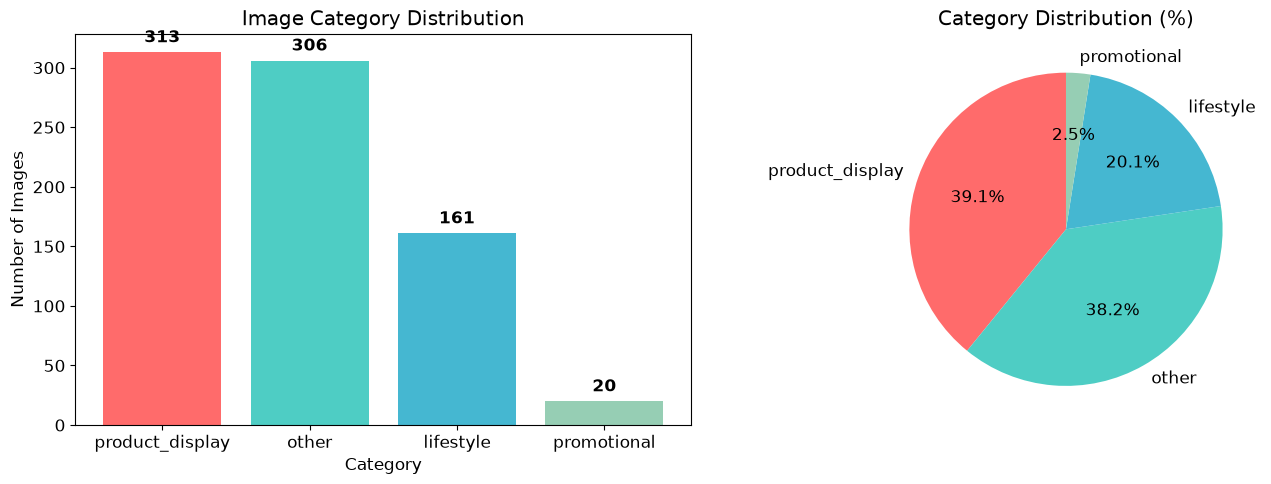

In [4]:
query = """
SELECT 
    image_category,
    COUNT(*) as count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as percentage
FROM \"1_marts\".fct_image_detections
GROUP BY image_category
ORDER BY count DESC;
"""

df_categories = pd.read_sql(query, conn)
print("Image Category Distribution:")
print(df_categories.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax1.bar(df_categories['image_category'], df_categories['count'], color=colors)
ax1.set_title('Image Category Distribution')
ax1.set_xlabel('Category')
ax1.set_ylabel('Number of Images')
for i, v in enumerate(df_categories['count']):
    ax1.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
ax2.pie(df_categories['count'], labels=df_categories['image_category'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Category Distribution (%)')
plt.tight_layout()
plt.show()

#### Views by Image Category (Key Insight!)

C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\4244391098.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_views = pd.read_sql(query, conn)


Views by Image Category:
 image_category  count  avg_views  median_views  min_views  max_views
    promotional     20   15589.95       15784.5        863      29920
          other    306    9689.98         655.5         13      34436
      lifestyle    161    7105.04         627.0         37      29969
product_display    313     594.58         344.0          0      13788


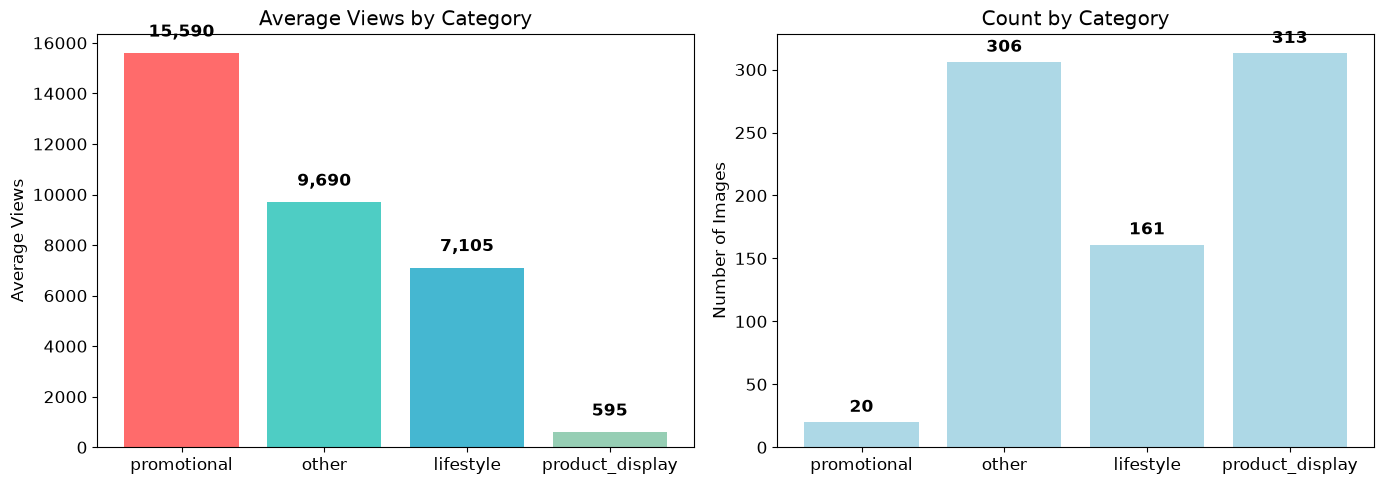


 KEY INSIGHT: Promotional posts get 26x more views than product display!
   Promotional: 15,590 avg views
   Product Display: 595 avg views


In [5]:
query = """
SELECT 
    image_category,
    COUNT(*) as count,
    ROUND(AVG(view_count)::numeric, 2) as avg_views,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY view_count)::numeric, 2) as median_views,
    MIN(view_count) as min_views,
    MAX(view_count) as max_views
FROM \"1_marts\".fct_image_detections
WHERE view_count IS NOT NULL
GROUP BY image_category
ORDER BY avg_views DESC;
"""

df_views = pd.read_sql(query, conn)
print("Views by Image Category:")
print(df_views.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df_views['image_category'], df_views['avg_views'], color=colors)
axes[0].set_title('Average Views by Category')
axes[0].set_ylabel('Average Views')
for i, v in enumerate(df_views['avg_views']):
    axes[0].text(i, v + 500, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].bar(df_views['image_category'], df_views['count'], color='lightblue')
axes[1].set_title('Count by Category')
axes[1].set_ylabel('Number of Images')
for i, v in enumerate(df_views['count']):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

promo_avg = df_views[df_views['image_category'] == 'promotional']['avg_views'].values[0]
product_avg = df_views[df_views['image_category'] == 'product_display']['avg_views'].values[0]
print(f"\n KEY INSIGHT: Promotional posts get {promo_avg/product_avg:.0f}x more views than product display!")
print(f"   Promotional: {promo_avg:,.0f} avg views")
print(f"   Product Display: {product_avg:,.0f} avg views")

#### Visual Content by Channel

C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\4139283010.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_channels = pd.read_sql(query, conn)
C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\4139283010.py:31: UserWarning: Glyph 129734 (\U0001fac6) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\4139283010.py:31: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Visual Content by Channel:
                  channel_name  total_images  product_shots  lifestyle_shots  promotional  pct_of_total
Lobelia pharmacy and cosmetics           270            165               19            0         33.75
               tikva | PHARMA🫆           229            108               54            0         28.63
             Doctors Online 🇪🇹           153              0               37           10         19.13
                        CheMed           148             40               51           10         18.50


c:\Users\sisay\OneDrive\Documents\kaim\medical-telegram-warehouse\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129734 (\U0001fac6) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sisay\OneDrive\Documents\kaim\medical-telegram-warehouse\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


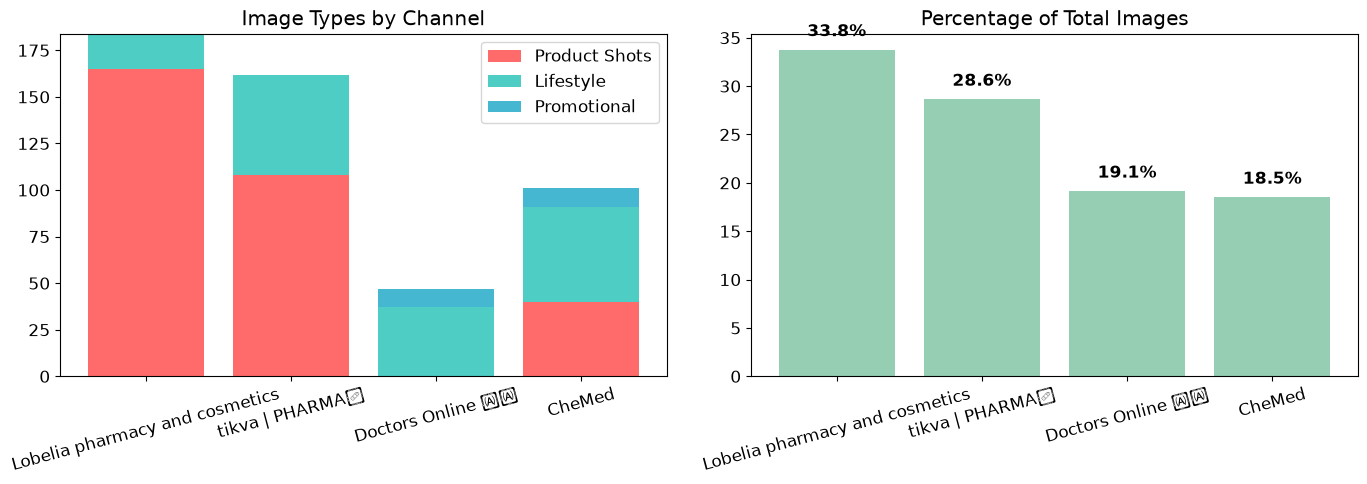

In [6]:
query = """
SELECT 
    c.channel_name,
    COUNT(id.message_id) as total_images,
    SUM(CASE WHEN id.is_product_display = 1 THEN 1 ELSE 0 END) as product_shots,
    SUM(CASE WHEN id.is_lifestyle = 1 THEN 1 ELSE 0 END) as lifestyle_shots,
    SUM(CASE WHEN id.is_promotional = 1 THEN 1 ELSE 0 END) as promotional,
    ROUND(100.0 * COUNT(id.message_id) / SUM(COUNT(id.message_id)) OVER (), 2) as pct_of_total
FROM \"1_marts\".fct_image_detections id
JOIN \"1_marts\".dim_channels c ON id.channel_key = c.channel_key
GROUP BY c.channel_name
ORDER BY total_images DESC;
"""

df_channels = pd.read_sql(query, conn)
print("Visual Content by Channel:")
print(df_channels.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(df_channels['channel_name'], df_channels['product_shots'], label='Product Shots', color='#FF6B6B')
ax1.bar(df_channels['channel_name'], df_channels['lifestyle_shots'], bottom=df_channels['product_shots'], label='Lifestyle', color='#4ECDC4')
ax1.bar(df_channels['channel_name'], df_channels['promotional'], bottom=df_channels['product_shots']+df_channels['lifestyle_shots'], label='Promotional', color='#45B7D1')
ax1.set_title('Image Types by Channel')
ax1.legend()
ax1.tick_params(axis='x', rotation=15)
ax2.bar(df_channels['channel_name'], df_channels['pct_of_total'], color='#96CEB4')
ax2.set_title('Percentage of Total Images')
for i, v in enumerate(df_channels['pct_of_total']):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

#### Category Distribution by Channel

In [9]:
query = """
SELECT 
    c.channel_name,
    id.image_category,
    COUNT(*) as count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY c.channel_name), 2) as percentage
FROM \"1_marts\".fct_image_detections id
JOIN \"1_marts\".dim_channels c ON id.channel_key = c.channel_key
WHERE id.image_category != 'other'
GROUP BY c.channel_name, id.image_category
ORDER BY c.channel_name, count DESC;
"""

df_category_channel = pd.read_sql(query, conn)
print("Category Distribution by Channel:")
print(df_category_channel.to_string(index=False))


Category Distribution by Channel:
                  channel_name  image_category  count  percentage
                        CheMed       lifestyle     51       50.50
                        CheMed product_display     40       39.60
                        CheMed     promotional     10        9.90
             Doctors Online 🇪🇹       lifestyle     37       78.72
             Doctors Online 🇪🇹     promotional     10       21.28
Lobelia pharmacy and cosmetics product_display    165       89.67
Lobelia pharmacy and cosmetics       lifestyle     19       10.33
               tikva | PHARMA🫆 product_display    108       66.67
               tikva | PHARMA🫆       lifestyle     54       33.33


C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\3572584738.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_category_channel = pd.read_sql(query, conn)


#### Top Detected Objects

C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\1737206324.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_objects = pd.read_sql(query, conn)


Top 10 Detected Objects:
top_detected_class  count  avg_confidence
            bottle    181           0.580
      refrigerator    105           0.647
            person     99           0.801
            laptop     73           0.896
              book     30           0.348
                tv     21           0.807
             clock     13           0.503
               cup     12           0.555
      potted plant      9           0.848
            orange      9           0.472


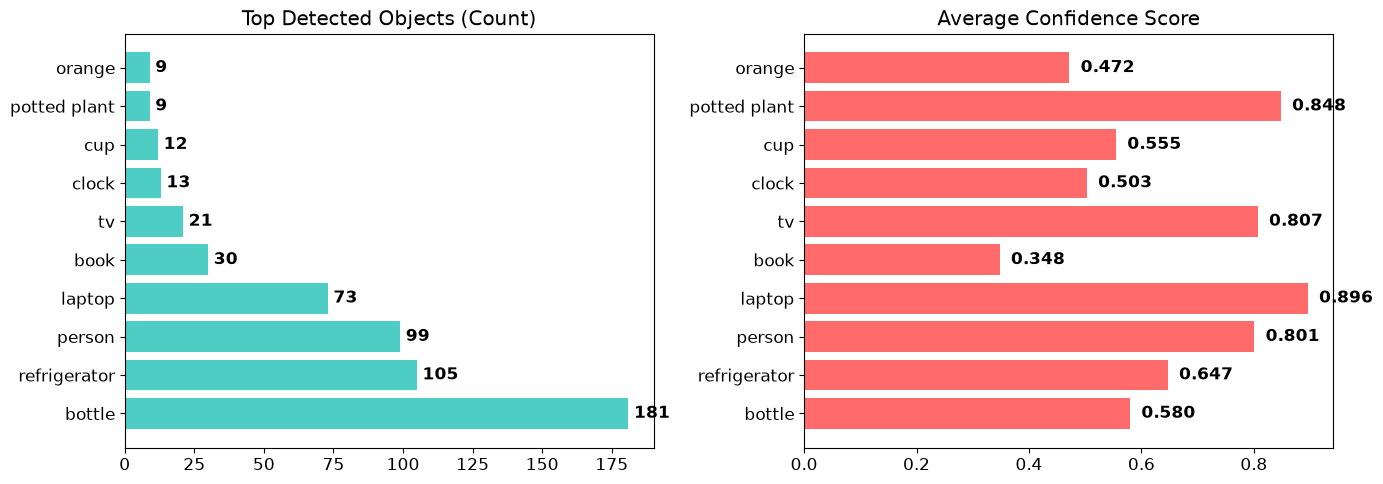

In [10]:
query = """
SELECT 
    top_detected_class,
    COUNT(*) as count,
    ROUND(AVG(top_confidence)::numeric, 3) as avg_confidence
FROM \"1_marts\".fct_image_detections
WHERE top_detected_class IS NOT NULL
GROUP BY top_detected_class
ORDER BY count DESC
LIMIT 10;
"""

df_objects = pd.read_sql(query, conn)
print("Top 10 Detected Objects:")
print(df_objects.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(df_objects['top_detected_class'], df_objects['count'], color='#4ECDC4')
axes[0].set_title('Top Detected Objects (Count)')
for i, v in enumerate(df_objects['count']):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')
axes[1].barh(df_objects['top_detected_class'], df_objects['avg_confidence'], color='#FF6B6B')
axes[1].set_title('Average Confidence Score')
for i, v in enumerate(df_objects['avg_confidence']):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

#### Summary Statistics

In [11]:
query = """
SELECT 
    'Total Images Analyzed' as metric,
    COUNT(*) as value
FROM \"1_marts\".fct_image_detections
UNION ALL
SELECT 
    'With Detections (>0 objects)' as metric,
    COUNT(*) as value
FROM \"1_marts\".fct_image_detections
WHERE total_objects > 0
UNION ALL
SELECT 
    'With People (Lifestyle + Promotional)' as metric,
    COUNT(*) as value
FROM \"1_marts\".fct_image_detections
WHERE is_lifestyle = 1 OR is_promotional = 1
UNION ALL
SELECT 
    'With Products (Product Display + Promotional)' as metric,
    COUNT(*) as value
FROM \"1_marts\".fct_image_detections
WHERE is_product_display = 1 OR is_promotional = 1;
"""

df_summary = pd.read_sql(query, conn)
print("Summary Statistics:")
print(df_summary.to_string(index=False))

Summary Statistics:
                                       metric  value
                        Total Images Analyzed    800
                 With Detections (>0 objects)    617
        With People (Lifestyle + Promotional)    181
With Products (Product Display + Promotional)    333


C:\Users\sisay\AppData\Local\Temp\ipykernel_14124\294641023.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_summary = pd.read_sql(query, conn)
